[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Dalam Proses Training...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.1100 - loss: 3.2900 - val_accuracy: 0.2329 - val_loss: 2.9367
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.2250 - loss: 2.8157 - val_accuracy: 0.2945 - val_loss: 2.5138
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.2976 - loss: 2.4269 - val_accuracy: 0.3562 - val_loss: 2.3196
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3682 - loss: 2.1635 - val_accuracy: 0.3288 - val_loss: 2.1774
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4140 - loss: 2.0414 - val_accuracy: 0.3493 - val_loss: 2.1335
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4565 - loss: 1.8817 - val_accuracy: 0.3562 - val_loss: 2.0496
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.4617 - loss: 1.6905 - val_accuracy: 0.4247 - val_loss: 1.9889
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5555 - loss: 1.5011 - val_accuracy: 0.4384 - val_l

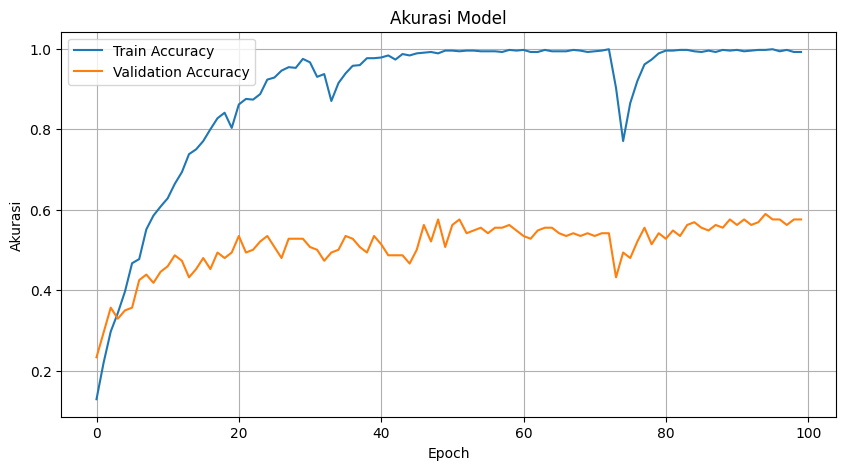

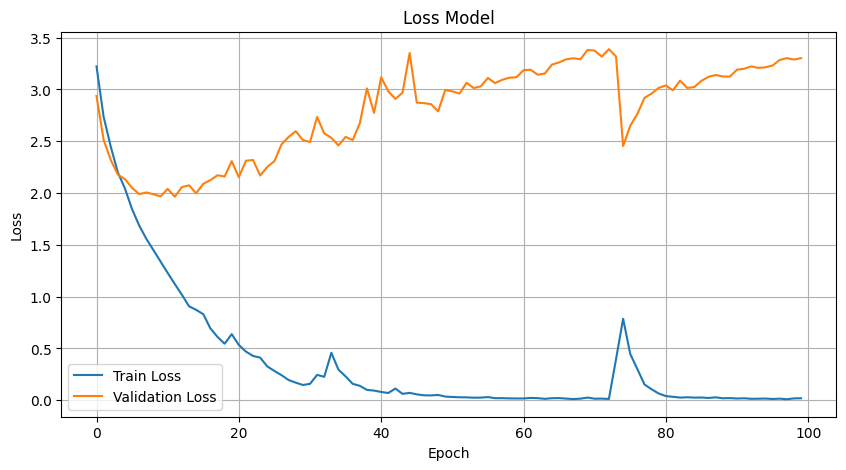

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step


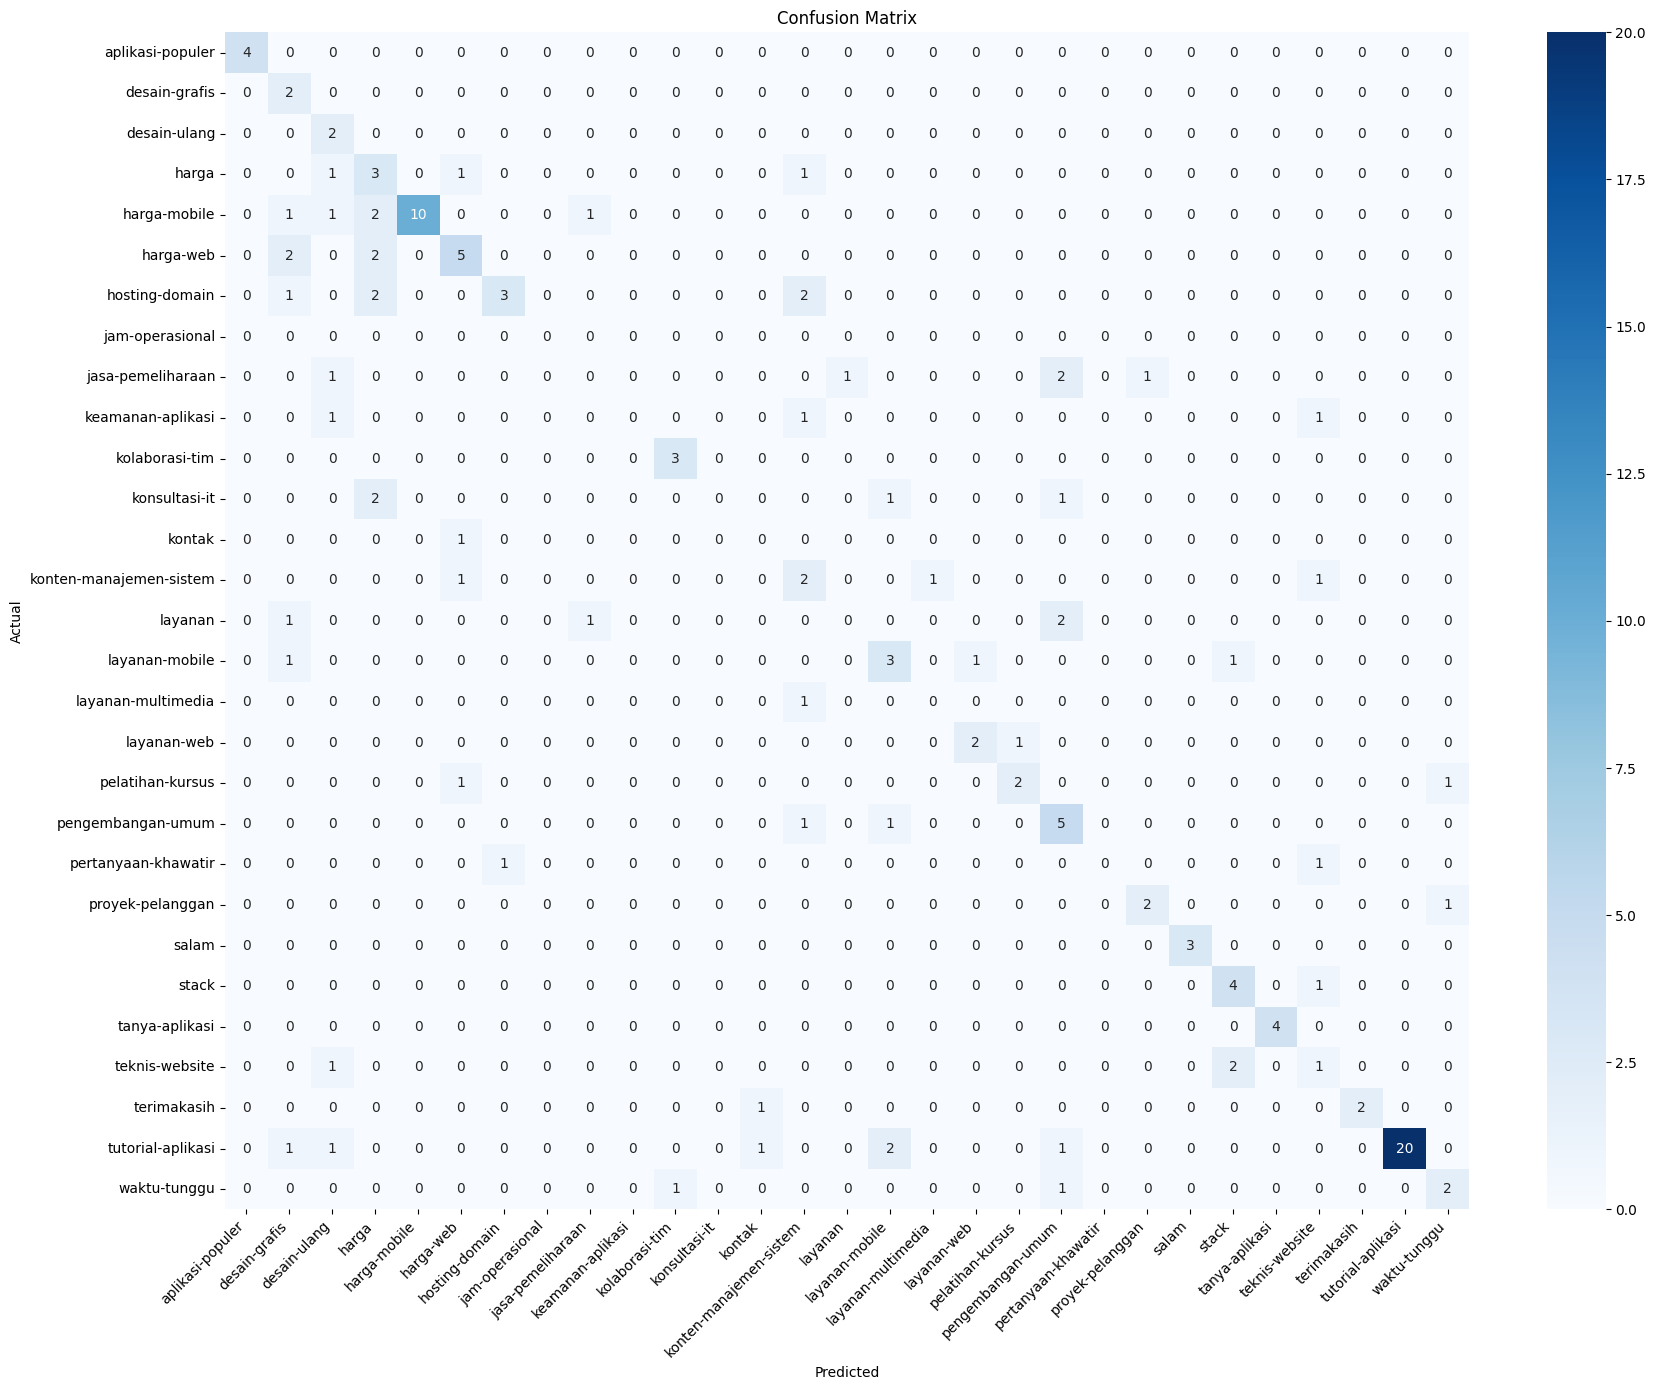


🧾 Classification Report:
                         precision    recall  f1-score   support

       aplikasi-populer       1.00      1.00      1.00         4
          desain-grafis       0.22      1.00      0.36         2
           desain-ulang       0.25      1.00      0.40         2
                  harga       0.27      0.50      0.35         6
           harga-mobile       1.00      0.67      0.80        15
              harga-web       0.56      0.56      0.56         9
         hosting-domain       0.75      0.38      0.50         8
        jam-operasional       0.00      0.00      0.00         0
      jasa-pemeliharaan       0.00      0.00      0.00         5
      keamanan-aplikasi       0.00      0.00      0.00         3
         kolaborasi-tim       0.75      1.00      0.86         3
          konsultasi-it       0.00      0.00      0.00         4
                 kontak       0.00      0.00      0.00         1
konten-manajemen-sistem       0.25      0.40      0.31         


 Final Accuracy: 57.53% | Loss: 3.3015
✅ Model berhasil disimpan ke chatbot_model.h5

 Chatbot siap! (Ketik 'quit' untuk keluar)
Kamu: Halo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Bot: Halo kak, ada yang bisa aku bantu?
Kamu: Aku mau tanya tanya tentang jasa pembuatan web
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Bot: Anda dapat menghubungi kami melalui kontak agen, email sampulkreativ@gmail.com, atau WhatsApp di 0851-7505-2477.
Kamu: kalau buat website berapa ya kak?
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Bot: Harga pengembangan website sangat bervariasi tergantung kompleksitas project yang kakak inginkan, Kakak bisa menjelaskan detail project tersebut kepada kontak agen untuk mendapat harga terbaik.
Kamu: Kalau pembuatan aplikasi android?
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Bot: Kami dapat membantu Anda dalam pengembangan aplikasi mobile. Silakan ceritakan kebutuhan anda kepada agen kami dengan klik Kontak Agent.


In [ ]:
import json
import string
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
import nltk
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

nltk.download('punkt_tab')

with open('intents-fix.json', encoding='utf-8') as file:
    data = json.load(file)

with open('combined_slang_words.txt', 'r', encoding='utf-8') as f:
    slang_dict = json.load(f)

def normalize_slang(tokens):
    return [slang_dict.get(word, word) for word in tokens]

texts = []
labels = []

for intent in data['intents']:
    for pattern in intent['patterns']:
        pattern = pattern.lower()
        pattern = pattern.translate(str.maketrans('', '', string.punctuation))
        tokens = word_tokenize(pattern)
        normalized = normalize_slang(tokens)
        final_text = ' '.join(normalized)
        texts.append(final_text)
        labels.append(intent['tag'])

le = LabelEncoder()
y = le.fit_transform(labels)
y = tf.keras.utils.to_categorical(y)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, padding='post')

X_train, X_test, y_train, y_test = train_test_split(padded, y, test_size=0.2, random_state=42)

embedding_index = {}
with open('id.vec', encoding='utf-8') as f:
    next(f)
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_dim = 300
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

embedding_layer = tf.keras.layers.Embedding(
    input_dim=len(word_index) + 1,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=padded.shape[1],
    trainable=False
)

def build_model(optimizer):
    model = tf.keras.Sequential([
        embedding_layer,
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(y.shape[1], activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

print("Dalam Proses Training...")
model = build_model(Adam(learning_rate=0.001))
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, verbose=1)

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

labels_str = le.classes_

cm = confusion_matrix(y_true, y_pred, labels=range(len(labels_str)))
df_cm = pd.DataFrame(cm, index=labels_str, columns=labels_str)

plt.figure(figsize=(18, 14))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n🧾 Classification Report:")
print(classification_report(
    y_true, y_pred,
    labels=range(len(labels_str)),
    target_names=labels_str,
    zero_division=0
))

loss, acc = model.evaluate(X_test, y_test)
print(f"\n Final Accuracy: {acc*100:.2f}% | Loss: {loss:.4f}")

# ✅ Simpan model ke format .h5
model.save('chatbot_model.h5')
print("✅ Model berhasil disimpan ke chatbot_model.h5")

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

def preprocess_input(text):
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    normalized = normalize_slang(tokens)
    final_text = " ".join(normalized)
    seq = tokenizer.texts_to_sequences([final_text])
    padded_input = pad_sequences(seq, maxlen=padded.shape[1], padding='post')
    return padded_input

def get_response(predicted_tag, intents_json):
    for intent in intents_json["intents"]:
        if intent["tag"] == predicted_tag:
            return np.random.choice(intent["responses"])
    return "aku ga pahaamm"

def chatbot():
    print("\n Chatbot siap! (Ketik 'quit' untuk keluar)")
    while True:
        user_input = input("Kamu: ")
        if user_input.lower() == 'quit':
            print("Bot: Sampai jumpa ya kak")
            break
        input_seq = preprocess_input(user_input)
        pred = model.predict(input_seq)[0]
        tag = le.inverse_transform([np.argmax(pred)])[0]
        response = get_response(tag, data)
        print("Bot:", response)

chatbot()
